Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów SVC, zmieniając (uargumentuj wybór):
   1. funkcję jądra
   1. paramety jądra
   1. parametr `C`
1. [0-1 pkt] W przeszukaniu wyżej użyj [walidacji krzyżowej](https://scikit-learn.org/stable/modules/cross_validation.html) odpowiedniej dla zbioru niezbalansowanego
1. [0-1.5 pkt] Zbadaj zależność liczby wektorów nośnych per klasa. W tym celu wykorzystaj atrybuty `support_vectors_` i/lub `decision_function`. Czy istnieje korelacja między liczbą wektorów nośnych a dokładnością klasyfikatora?
2. [0-1 pkt] Podobnie jak w poprzednim zadaniu, zbadaj dokładność modelu w zależności od techniki skalowania oraz wyboru liczby cech
3. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyrysuj obszary decyzyjne. Weź pod uwagę, że implementacja w `scikit-learn`  działa na zasadzie OvR (*One-vs-Rest*) tzn. każdy klasyfikator uczy się oddzielnej hiperpowierzchni dla swojej klasy. Skomentuj wyniki
1. [0-1 pkt] Porównaj wyniki najlepszego modelu z `LinearSVC` z domyślnymi parametrami. Użyj MCC jako miary do porównania (uwzględnij odchylenie standardowe po podziałach w walidacji krzyżowej). Skomentuj wynik
1. [0-1 pkt] Czy w świetle uzyskanych wyników, SVC jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
1. [0-1.5 pkt] Zidentyfikuj używkę, z którą model radzi sobie najlepiej. Analiza nie musi być tak zaawansowana jak wyżej, ale powinna miarodajnie porównać wszystkie klasyfikatory między sobą. Efektywnie, chodzi o zaimplementowanie pętli po zmiennej `y` i odpowiednie dobranie parametrów w `GridSearchCV` oraz `Pipeline`
   
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

# Krok 0. Załadowanie danych

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import matthews_corrcoef, make_scorer, f1_score
from sklearn.inspection import DecisionBoundaryDisplay
from ucimlrepo import fetch_ucirepo


In [ ]:
drugs = fetch_ucirepo(id=373) 
X = drugs.data.features.copy()
y_all = drugs.data.targets.copy()
y = y_all.crack

In [52]:
X.shape, len(y)

((1885, 12), 1885)

# Krok 1. Preprocessing danych

Brakujące dane

In [53]:
X[pd.isna(X).any(axis=1)]

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss


Usunięcie danych związanych z wymyślonym narkotykiem `semer`

In [54]:
idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

Sprawdzamy ile mamy danych wartości per klasa

In [55]:
y.value_counts()

crack
CL0    1622
CL2     109
CL1      67
CL3      59
CL5       9
CL4       9
CL6       2
Name: count, dtype: int64

Ze względu na niewielką liczbę elementów o klasie `CL4`, `CL5`, `CL6` możemy je usunąć

In [56]:
classes_to_drop = ['CL4', 'CL5', 'CL6']
idx_to_drop = y[y.isin(classes_to_drop)].index

X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

In [57]:
y.value_counts()

crack
CL0    1622
CL2     109
CL1      67
CL3      59
Name: count, dtype: int64

# Zmienne kategoryczne i podział na zbiór treningowy i testowy

In [58]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Zadanie 1 i 2

Na początek wyznaczamy optymalne parametry dla `SVM` wykorzystując `GridSearchCV` z różnymi jądrami. Następnie wykorzystujemy walidację krzyżową dla zbioru niezbalansowanego

In [59]:
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(random_state=42, class_weight='balanced', decision_function_shape='ovr'))
])

param_grid = {
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__C': [0.1, 1, 10, 100],
    'svc__degree': [2, 3]
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipe_svc, param_grid, cv=cv_strat, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy wynik (F1-macro): {grid_search.best_score_:.3f}")

Najlepsze parametry: {'svc__C': 1, 'svc__degree': 3, 'svc__kernel': 'poly'}
Najlepszy wynik (F1-macro): 0.339


Wyniki otrzymalne dla najlepszego modelu są `wielomianową` funkcją jądra. Pokazuje to, że model potrafi dopasować się nie tworząc skomplikowanych "wysp" punktów do datasetu. Warto wspomnieć o niewielkim kosztcie jakim jest `C=1`. Wynik `f1` na poziomie `34%` może wydawać się niewielki, jednak przy tak mocno niezbalansowanym modelu i 4 klasach niekoniecznie jest negatywne. Na pewno pokazuje ta metryka prawdziwą stronę tego modelu, ponieważ testując inne metryki jak np `accuracy` otrzymałem wynik `79%` co jak widać mocno zakłamało odbiór jakości modelu

# Zadanie 3

Tutaj weźmiemy najlepszy model `SVM` jaki otrzymaliśmy i sprawdzimy, ile jest wektorów nośnych per klasa.

In [60]:
best_svc = grid_search.best_estimator_.named_steps['svc']
print("Liczba wektorów nośnych per klasa:")
for i, cls_name in enumerate(le.classes_):
    print(f"Klasa {cls_name}: {best_svc.n_support_[i]}")

print("\n")

c_values = [0.01, 1, 100]
for c in c_values:
    temp_pipe = Pipeline([
        ('s', StandardScaler()), 
        ('svc', SVC(C=c, class_weight='balanced', kernel=best_svc.kernel, random_state=42))
    ]).fit(X_train, y_train)
    
    y_pred = temp_pipe.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    total_sv = sum(temp_pipe.named_steps['svc'].n_support_)
    
    print(f"C={c:6} | Suma liczby wektorów nośnych: {total_sv:4} | F1-macro: {f1:.3f}")

Liczba wektorów nośnych per klasa:
Klasa CL0: 1092
Klasa CL1: 51
Klasa CL2: 85
Klasa CL3: 44


C=  0.01 | Suma liczby wektorów nośnych: 1477 | F1-macro: 0.275
C=     1 | Suma liczby wektorów nośnych: 1272 | F1-macro: 0.350
C=   100 | Suma liczby wektorów nośnych:  871 | F1-macro: 0.294


Łatwo zauważyć, że zdecydowanie najwięcej wektorów nośnych mamy dla klasy `CL0`, ale jest ona również najliczniejsza. Co ciekawe, im bardziej zwiększamy `C`, tym bardziej spada nam liczba wektorów nośnych. Może być to spowodowane mniejszą tolerancją modelu na błędy

# Zadanie 4

Podobnie jak w zadaniu 3, sprawdzimy liczbę wektorów nośnych, w zależności tym razem od skalera oraz liczby cech

In [61]:
scalers = [StandardScaler(), MinMaxScaler()]
k_features = [i for i in range(2, 13)]

print("Badanie zależności: Skalowanie i Liczba Cech vs F1-macro")
print("-" * 60)

for scaler in scalers:
    for k in k_features:
        temp_pipe = Pipeline([
            ('scaler', scaler),
            ('selector', SelectKBest(f_classif, k=k)),
            ('svc', SVC(C=grid_search.best_params_['svc__C'], 
                        kernel=grid_search.best_params_['svc__kernel'], 
                        class_weight='balanced', 
                        random_state=42))
        ])
        
        scores = cross_val_score(temp_pipe, X_train, y_train, cv=cv_strat, scoring='f1_macro')
        
        scaler_name = scaler.__class__.__name__
        print(f"Skaler: {scaler_name:15} | Cechy (k): {k:2} | F1: {scores.mean():.3f}")

Badanie zależności: Skalowanie i Liczba Cech vs F1-macro
------------------------------------------------------------
Skaler: StandardScaler  | Cechy (k):  2 | F1: 0.285
Skaler: StandardScaler  | Cechy (k):  3 | F1: 0.271
Skaler: StandardScaler  | Cechy (k):  4 | F1: 0.325
Skaler: StandardScaler  | Cechy (k):  5 | F1: 0.325
Skaler: StandardScaler  | Cechy (k):  6 | F1: 0.308
Skaler: StandardScaler  | Cechy (k):  7 | F1: 0.306
Skaler: StandardScaler  | Cechy (k):  8 | F1: 0.312
Skaler: StandardScaler  | Cechy (k):  9 | F1: 0.301
Skaler: StandardScaler  | Cechy (k): 10 | F1: 0.310
Skaler: StandardScaler  | Cechy (k): 11 | F1: 0.324
Skaler: StandardScaler  | Cechy (k): 12 | F1: 0.339
Skaler: MinMaxScaler    | Cechy (k):  2 | F1: 0.225
Skaler: MinMaxScaler    | Cechy (k):  3 | F1: 0.222
Skaler: MinMaxScaler    | Cechy (k):  4 | F1: 0.248
Skaler: MinMaxScaler    | Cechy (k):  5 | F1: 0.275
Skaler: MinMaxScaler    | Cechy (k):  6 | F1: 0.260
Skaler: MinMaxScaler    | Cechy (k):  7 | F1: 0.27

Analizując uzyskane wyniki łatwo można dość do konkluzji, że `StandardScaler` jest lepszym rozwiązaniem niż `MinMaxScaler`. Jest to spowodowane charakerystyką modeli `SVM`, które wymagają znormalizowanych danych. Łatwo też zauważyć, że dla obu skalerów najlepsze wyniki model osiągnąć dla maksymalnej liczby cech, czyli `k=12`. Jest to dobra wiadomość, ponieważ pokazuje to, że wszystkie dane mają jakość znaczącą wartość dla modelu a nie są zbędne

# Zadanie 5

W tym zadaniu wybierzemy dwie najważniejsze cechy oraz narysujemy wykres pokazujący obszary, dla których model przewiduje że tam znajdują się obiekty danej klasy

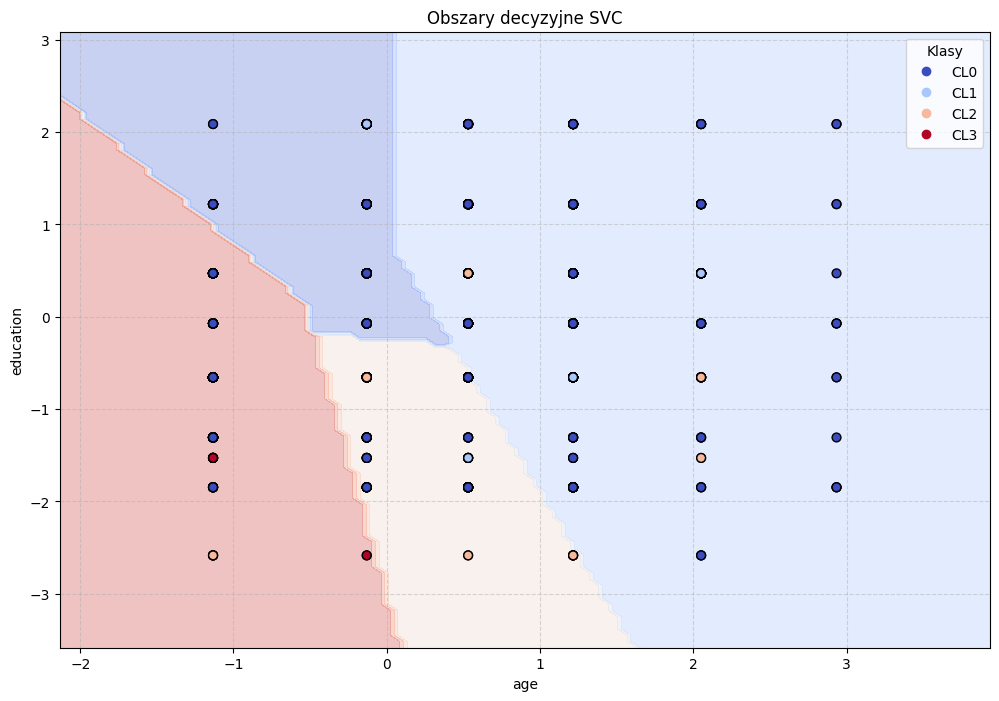

In [62]:
scaler_2d = StandardScaler()
X_scaled_2d = scaler_2d.fit_transform(X_train)

selector_2d = RFE(estimator=SVC(kernel='linear'), n_features_to_select=2)
selector_2d.fit(X_scaled_2d, y_train)

selected_features_names = selector_2d.get_feature_names_out(input_features=X.columns)

X_train_final_2d = selector_2d.transform(X_scaled_2d)

svc_decision_plot = SVC(kernel='linear', C=1.0, class_weight='balanced', decision_function_shape='ovr')
svc_decision_plot.fit(X_train_final_2d, y_train)

plt.figure(figsize=(12, 8))

DecisionBoundaryDisplay.from_estimator(
    svc_decision_plot, 
    X_train_final_2d, 
    response_method="predict", 
    alpha=0.3, 
    cmap=plt.cm.coolwarm,
    ax=plt.gca()
)

scatter = plt.scatter(
    X_train_final_2d[:, 0], 
    X_train_final_2d[:, 1], 
    c=y_train, 
    edgecolors='k', 
    cmap=plt.cm.coolwarm,
    s=40
)

handles, _ = scatter.legend_elements()
plt.legend(handles, le.classes_, title="Klasy", loc="upper right")

plt.title(f"Obszary decyzyjne SVC")
plt.xlabel(selected_features_names[0])
plt.ylabel(selected_features_names[1])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Na wykresie widać dość duże niedopasowanie obiektów klasy `CL0` na polach dla klasy `CL1`, `CL2` i `CL3`. Jest to spowodowane metodą, jaka jest wykorzystywana, gdy mamy wiele klas w `SVM`. `One-vs-rest(OvR)` łączy wszystkie klasy które nie są sprawdzane w jedną, i wyznacza na tej podstawie linie/płaszyczyznę dla sprawdzanej klasy. Właśnie to spowodowało, że obszar dla `CL1` jest tak duży i zawiera w sobie dużo elementów z klasy `CL0`, ponieważ przy wyznaczaniu linii dla `CL1` punktu `CL0`, `CL2` i `CL3` były jednym zbiorem i stosunkowo tak niewielka ilość punktów w przeciwnym zbiorze była jak najbardziej akceptowalna Analogiczna sytuacja wystąpiła dla klasyfikacji obszarów dla `CL2` i `CL3`. Poza tym, uważam że dość dobrze zostały obszary podzielone patrząc na fakt, jak bardzo niejednoznaczy jest ten dataset i punkty nie znajdują się w zbitych grupkach ułatwiających wyznaczanie obszarów danych klas. Dodatkowo wykorzystwane klasy wybrane jako dwie najważniejsze mają dość dużo sensu patrząc na problem, z jakim spotykamy się w tym datasetcie

# Zadanie 6 i 7

W tym zadnaiu wykorzystamy `LinearSVC` i porównamy otrzymane wyniki w porównaniu do `SVC` najlepszego modelu. 

In [63]:
mcc_scorer = make_scorer(matthews_corrcoef)

svc_mcc = cross_val_score(grid_search.best_estimator_, X, y_encoded, cv=cv_strat, scoring=mcc_scorer)

lsvc_pipe = Pipeline([
    ('s', StandardScaler()), 
    ('lsvc', LinearSVC())
])
lsvc_mcc = cross_val_score(lsvc_pipe, X, y_encoded, cv=cv_strat, scoring=mcc_scorer)

print(f"SVC MCC: {svc_mcc.mean():.3f} (+/- {svc_mcc.std():.3f})")
print(f"LinearSVC MCC: {lsvc_mcc.mean():.3f} (+/- {lsvc_mcc.std():.3f})")

SVC MCC: 0.168 (+/- 0.031)
LinearSVC MCC: 0.000 (+/- 0.000)


Model `LinearSVC` kompletnie nie dał rady i okazało się, że jest on tak samo dobry jak losowy rzut monetą. Najlepszy model `SVC` daje zdecydowanie lepsze wyniki i pokazuje, że ustaiwanie odpowiednich wartości kernela ma sens i przynosi dobre wyniki. Wynik `MCC` na poziomie niecałych `0.2` pokazuje, że jest to dość trudny problem dla tego datasetu i raczej szukałbym innego rozwiązania.

# Zadanie 8

W tym zadaniu bierzemy każdy narkotyk i testujemy jakie wyniki dla niego osiąga nasz model. W tym celu tym razem wykorzystamy `GridSearchCV` do wyboru optymalnych parametrów jądra oraz zrobimy uproszczony preprocessing

In [65]:
substances = drugs.data.targets.columns.drop('semer')
substance_results = {}

param_grid = {
    'svc__kernel': ['linear', 'rbf'],
    'svc__C': [0.1, 1, 10]
}


for drug in substances:
    y_sub_raw = drugs.data.targets[drug]
    
    counts = y_sub_raw.value_counts()
    valid_classes = counts[counts >= 10].index
    mask = y_sub_raw.isin(valid_classes)
        
    X_sub = drugs.data.features[mask]
    y_sub_enc = le.fit_transform(y_sub_raw[mask])
    
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(class_weight='balanced', random_state=42))
    ])
    
    grid = GridSearchCV(
        pipe, 
        param_grid, 
        cv=StratifiedKFold(n_splits=3), 
        scoring=mcc_scorer, 
        n_jobs=-1
    )
    
    grid.fit(X_sub, y_sub_enc)
    substance_results[drug] = grid.best_score_

sorted_results = sorted(substance_results.items(), key=lambda x: x[1], reverse=True)
best_drug = sorted_results[0][0]

print(f"Najlepszy wynik dla: {best_drug.upper()} (MCC: {substance_results[best_drug]:.3f})\n")

print("Ranking wszystkich narkotyków:")
for d, score in sorted_results:
    print(f"{d:10}: {score:.3f}")

Najlepszy wynik dla: LSD (MCC: 0.285)

Ranking wszystkich narkotyków:
lsd       : 0.285
legalh    : 0.251
mushrooms : 0.244
amphet    : 0.212
cannabis  : 0.200
vsa       : 0.191
coke      : 0.183
meth      : 0.179
amyl      : 0.179
ecstasy   : 0.173
benzos    : 0.169
crack     : 0.167
heroin    : 0.162
ketamine  : 0.157
nicotine  : 0.123
alcohol   : 0.065
caff      : 0.052
choc      : 0.047


Jak możemy zauważyć, najlepszy wynik mamy dla `LSD`. Może to wynikać z dobrze zdefiniowanego datasetu tego narkotyku, ponieważ jest on znany i zapewne dobrze przebadany. Dodatkowo jest to tak wyróżniający się narkotyk, że łatwiej jest rozróżnić, czy dana osoba go zażywa czy nie. Ogólnie MCC dla tych modeli nie jest zadowalające (co pokazuje że ten problem jest za trudny na tak skomplikowany dataset) i lepszym rozwiązaniem mogłoby być np zsumowanie wszystkich biorących danych narkotyk i niebiorących do dwóch oddzielnych klas i wyniki mogłyby być zdecydowanie lepsze